In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "main.py").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Working directory set to:", PROJECT_ROOT)

Working directory set to: /Users/navidv/GitHub/QuEP


In [3]:
%%writefile input/ATF_1D_lens.py
#This line will create betatron_example.py input file in the subfolder 'input'.

simulation_name = 'QUASI3D'  
#Explanation in README file. All simulations should have this as simulation name

shape = 'single'    
#betatron test only uses a singlular electron. See other options in README file for other sims

iterations = 1000000
#Iterations refers to the amount of times the code is run. The input conditions are put into equations using main.py.
#A high number of iterations will have less space between each 't' value used which will have increased clarity in graphs

mode = -1 
#mode 0 is the wakefield, mode 1 is the laser, mode -1 is both. Betatron is to see electron in wakefield
#(optional) If calculations includes laser, include the region of laser (not needed if mode =0)
# Order does not matter; the code will sort them.
# laser_xi_start = -16
# laser_xi_end = -1.5

fname = "ATF_1D_lens.npz"
#main.py will put the data from the simulation into this file. name it whatever you want your data file to be

debugmode = True
#debugmode should only be true for single electron simulations (I'm not actually sure why)


# Probe centered at the following initial coordinates (in c/w_p):
#See figure 3.1 in Evan Trommer's thesis. The goal is to put the electron in line with the peak of the second bump of the field
#so while xi_c here is fairly fixed y_c can be any range of values still within the bubble
x_c = -2 #
y_c = 0.5 #
xi_c = -13

# Initial momentum
#set initial transverse momentum to zero and pz_0=20 (or any other number)
px_0 = 110  
py_0 = 0
pz_0 = 0

# Screen Distances (from z-axis of plasma cell, in mm):
x_s = [10, 50, 100, 250, 500]

# Shape Parameters (Radius or Side Length, in c/w_p):
s1 = 1 # In y
s2 = 1 # In xi

# Densities
#you only have a single electron so there should just be one when you count on any axis
ydensity = 1
xidensity = 1
xdensity = 1 # Probe width - single layer
resolution = None 

#Simulation specific parameters
simulation_name = "QUASI3D"
quasi_id = "000130"
quasi_data_dir = "data/OSIRIS/Quasi3D"
quasi_density = 1e21 #in m^-3
quasi_propagation_speed = 1.0
dt_safety_factor = 0.1 #this is multiplied by dz

Overwriting input/ATF_1D_lens.py


In [4]:
#make sure to run from ~/GitHub/QuEP
%reset -f
%run main.py input.ATF_1D_lens

Start Time:  16:16:16
Using initial conditions from  input.ATF_1D_lens
Using laser vector-potential region:
  xi range: -25.01072525068368 -0.009734406087744674
  index range: 0 25230
Probe initialized...
Number of objects: 1
Using laser vector-potential region:
  xi range: -25.01072525068368 -0.009734406087744674
  index range: 0 25230
Using Debug Mode...
Tracking quit due to particle leaving cell
Debug object created...
End Time:  16:17:04
Duration:  0.7992105523745219  min
Debug object saved to data/ATF_1D_lens-DEBUG.obj


In [5]:
%reset -f

import gc
import importlib
import pickle
import sys

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

print("Working directory set to:", PROJECT_ROOT)


# Clean up memory from earlier notebook cells.
gc.collect()

# -----------------------------------------------------------------------------
# Load the user input file
# -----------------------------------------------------------------------------
# Use the module name, not the .py or .npz filename.
# For input/betatron_tutorial_input.py, use "input.betatron_tutorial_input" if
input_module = "input.ATF_1D_lens"
init = importlib.import_module(input_module)

# -----------------------------------------------------------------------------
# Configure the Quasi3D field infrastructure
# -----------------------------------------------------------------------------
import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load the debug trajectory object
# -----------------------------------------------------------------------------
debug_file = PROJECT_ROOT / "data" / "ATF_1D_lens-DEBUG.obj"

with open(debug_file, "rb") as file:
    debug_loaded = pickle.load(file)

# main.py saves Debug as a one-element list/tuple in this tutorial case.
debug = debug_loaded[0] if isinstance(debug_loaded, (list, tuple)) else debug_loaded

print(f"Loaded input module: {init.__name__}")
print(f"Loaded debug file:   {debug_file}")
print("\nThe Debug object contains the following saved simulation quantities:")
for key, value in debug.__dict__.items():
    print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Using laser vector-potential region:
  xi range: -25.01072525068368 -0.009734406087744674
  index range: 0 25230
Loaded input module: input.ATF_1D_lens
Loaded debug file:   /Users/navidv/GitHub/QuEP/data/ATF_1D_lens-DEBUG.obj

The Debug object contains the following saved simulation quantities:
x_dat                 type=ndarray          shape=(1, 48541)
y_dat                 type=ndarray          shape=(1, 48541)
z_dat                 type=ndarray          shape=(1, 48541)
xi_dat                type=ndarray          shape=(1, 48541)
Fx_dat                type=ndarray          shape=(1, 48541)
Fy_dat                type=ndarray          shape=(1, 48541)
Fz_dat                type=ndarray          shape=(1, 48541)
px_dat                type=ndarray          shape=(1, 48541)
py_dat                type=ndarray          shape=(1, 48541)
pz_dat                type=ndarray          shape=(1, 48541)


In [9]:
#Defining functions that allows fields to be called as needed
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from a DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay debug trajectories."""
    r_dat, xi_dat = get_r_xi_from_debug(debug)

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for i in range(r_dat.shape[0]):
        ax.plot(
            xi_dat[i, :],
            r_dat[i, :],
            color="black",
            linewidth=1.5,
            label="debug trajectory" if i == 0 else None,
        )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if r_dat.shape[0] > 0:
        ax.legend(loc="best")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


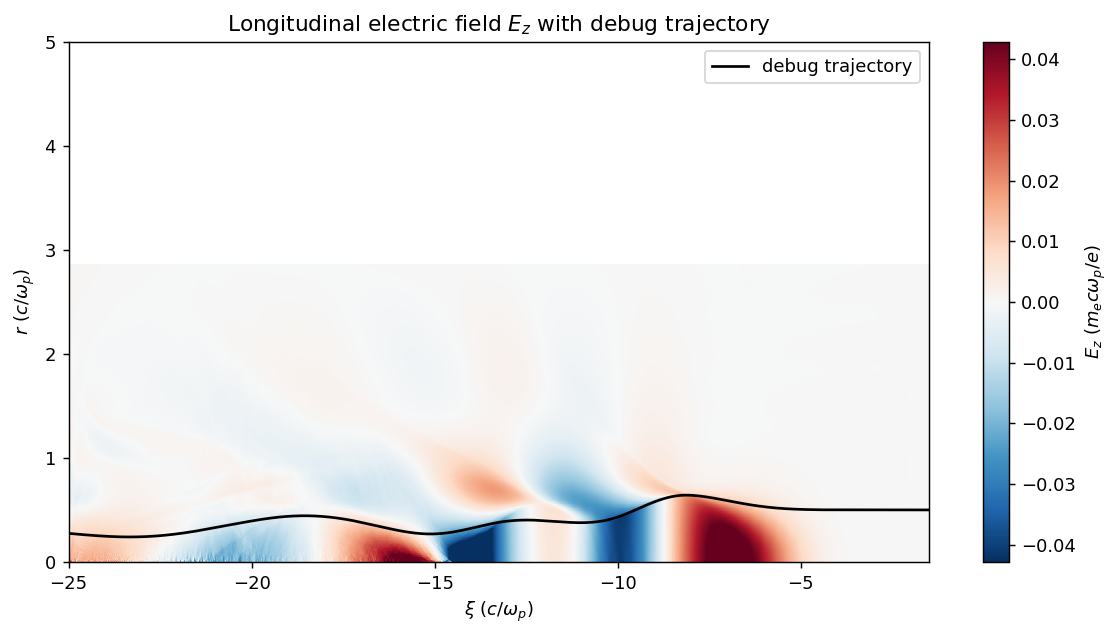

In [10]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debug,
    title=r"Longitudinal electric field $E_z$ with debug trajectory",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    xlim=(-25, -1.5), #for the 1D lens
    # xlim=(1, 3),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)

In [6]:
# Defining functions that allow fields and debug trajectories to be called as needed.

def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_debug_quantity(debug, quantity):
    """
    Extract a trajectory quantity from one DebugObject.

    quantity can be:
        - "xi_dat", "x_dat", "y_dat", "Fx_dat", "Fy_dat", etc.
        - "r_dat" for sqrt(x_dat^2 + y_dat^2)
        - a function, e.g. lambda debug: debug.Fx_dat + debug.Fy_dat
    """
    #callable is used to return a custom variable defined by a function
    if callable(quantity):
        return as_2d(quantity(debug))

    if quantity == "r_dat":
        x_dat = as_2d(debug.x_dat)
        y_dat = as_2d(debug.y_dat)
        return np.sqrt(x_dat**2 + y_dat**2)

    if not hasattr(debug, quantity):
        raise AttributeError(f"Debug object does not have attribute '{quantity}'.")

    return as_2d(getattr(debug, quantity))


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis=None,
    y_axis=None,
    field=None,
    debug_objects=None,
    *,
    trajectory_quantity="r_dat",
    trajectory_label=None,
    xi_quantity="xi_dat",
    title,
    field_label=None,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
    show_field=True,
):
    """
    Plot debug trajectories versus xi.

    If field, xi_axis, and y_axis are provided and show_field=True,
    the function also plots the field as a background pcolormesh.

    trajectory_quantity can be:
        "r_dat"
        "x_dat"
        "y_dat"
        "Fx_dat"
        "Fy_dat"
        or a custom function, e.g.
        lambda debug: debug.Fx_dat + debug.Fy_dat
    Setting show_field as false allows you to plot without the field. 
    """

    if debug_objects is None:
        raise ValueError("debug_objects must be provided.")

    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    plot_background_field = (
        show_field
        and field is not None
        and xi_axis is not None
        and y_axis is not None
    )

    if plot_background_field:
        if vmin is None or vmax is None:
            auto_vmin, auto_vmax = symmetric_color_limits(field)
            vmin = auto_vmin if vmin is None else vmin
            vmax = auto_vmax if vmax is None else vmax

        mesh = ax.pcolormesh(
            xi_axis,
            y_axis,
            field,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = fig.colorbar(mesh, ax=ax)
        if field_label is not None:
            cbar.set_label(field_label)

    for debug in debug_objects:
        xi_dat = get_debug_quantity(debug, xi_quantity)
        y_dat = get_debug_quantity(debug, trajectory_quantity)

        tag = getattr(debug, "tag", None)

        for i in range(y_dat.shape[0]):
            label = tag if i == 0 else None
            ax.plot(
                xi_dat[i, :],
                y_dat[i, :],
                linewidth=1.5,
                label=label,
            )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")

    if trajectory_label is not None:
        ax.set_ylabel(trajectory_label)
    elif isinstance(trajectory_quantity, str):
        ax.set_ylabel(trajectory_quantity)
    else:
        ax.set_ylabel("trajectory quantity")

    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if len(debug_objects) > 0:
        ax.legend(loc="best", title="particle")

    fig.tight_layout()
    plt.show()

    
def plot_debug_trajectory_quantities(
    debug_objects,
    trajectory_quantities,
    *,
    xi_quantity="xi_dat",
    title="Debug trajectory quantities",
    xlabel=r"$\xi$ $(c/\omega_p)$",
    ylabel=None,
    xlim=None,
    ylim=None,
    use_separate_axes=False,
):
    """
    Plot one or more trajectory quantities versus xi.

    Parameters
    ----------
    debug_objects :
        A single debug object or a list of debug objects.

    trajectory_quantities :
        List of quantities to plot. Each entry should be either:

            ("label", "attribute_name")

        or

            ("label", function)

        Examples:
            ("x", "x_dat")
            ("Fx", "Fx_dat")
            (r"$F_\perp$", lambda debug: np.sqrt(debug.Fx_dat**2 + debug.Fy_dat**2))

    use_separate_axes :
        If False, all quantities are plotted on the same y-axis.
        If True, each quantity gets its own subplot.
    """

    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    # Allow user to pass a single quantity without wrapping it in a list.
    if isinstance(trajectory_quantities, tuple):
        trajectory_quantities = [trajectory_quantities]

    n_quantities = len(trajectory_quantities)

    if use_separate_axes:
        fig, axes = plt.subplots(
            n_quantities,
            1,
            figsize=(9, 3.2 * n_quantities),
            dpi=130,
            sharex=True,
        )

        if n_quantities == 1:
            axes = [axes]

    else:
        fig, ax = plt.subplots(figsize=(9, 5), dpi=130)
        axes = [ax] * n_quantities

    for q_index, (quantity_label, quantity) in enumerate(trajectory_quantities):
        ax = axes[q_index]

        for debug_index, debug in enumerate(debug_objects):
            xi_dat = get_debug_quantity(debug, xi_quantity)
            y_dat = get_debug_quantity(debug, quantity)

            tag = getattr(debug, "tag", None)

            for particle_index in range(y_dat.shape[0]):
                if tag is not None:
                    label = f"{quantity_label}, {tag}" if particle_index == 0 else None
                else:
                    label = quantity_label if debug_index == 0 and particle_index == 0 else None

                ax.plot(
                    xi_dat[particle_index, :],
                    y_dat[particle_index, :],
                    linewidth=1.5,
                    label=label,
                )

        if use_separate_axes:
            ax.set_ylabel(quantity_label)
            ax.legend(loc="best")

    if use_separate_axes:
        axes[-1].set_xlabel(xlabel)

        for ax in axes:
            if xlim is not None:
                ax.set_xlim(*xlim)
            if ylim is not None:
                ax.set_ylim(*ylim)

    else:
        ax.set_xlabel(xlabel)

        if ylabel is not None:
            ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel("trajectory quantity")

        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.legend(loc="best")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

/var/folders/5x/bhvnl00x2g3brb1rh5h_13p80000gn/T/ipykernel_13402/2932102430.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", title="particle")


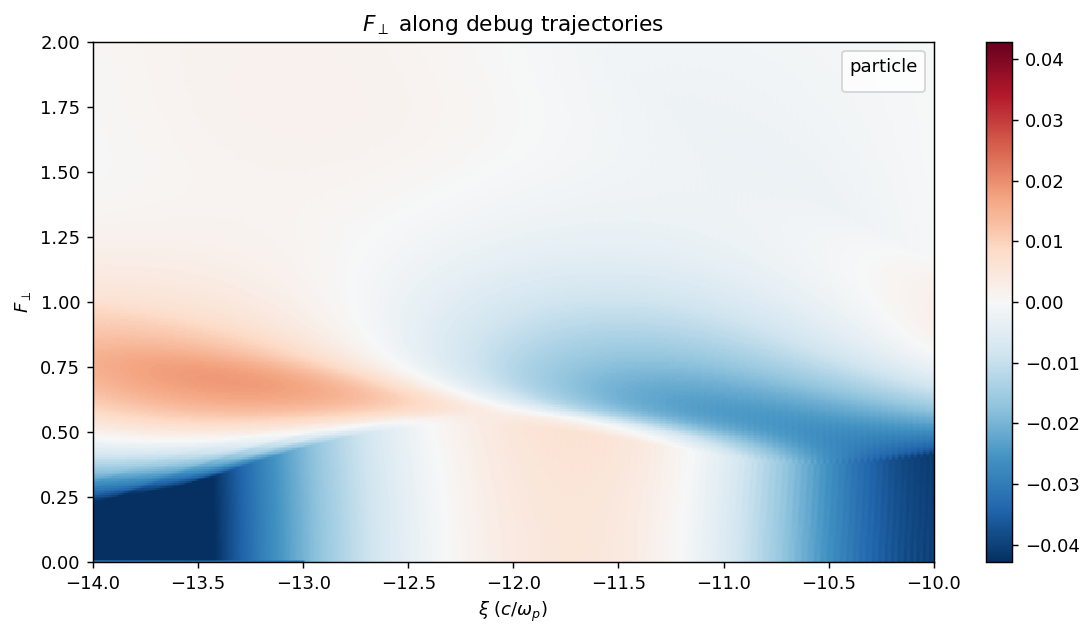

In [12]:
plot_field_with_debug_trajectories(
    debug_objects=debug,
    xi_axis=sim.xiaxis_1,
    y_axis=sim.raxis_1,
    field=sim.E1_M0,
    trajectory_quantity="py_dat",
    trajectory_label=r"$F_\perp$",
    title=r"$F_\perp$ along debug trajectories",
    xlim=(-14,-10),
    ylim=(0,2),
    show_field=True,
)